# 估值（市盈率静 / 市净率）与隔夜均值收益的相关性

**隔夜收益**：`text/overnight_leg_symbol_return_rank.csv` 中的 `mean_overnight_r`（回测期内、策略实际持仓上的隔夜 open/close−1 样本均值）。

**估值**：Tushare `daily_basic` 落盘 `data/<YYYYMMDD>/quote/basic/*.csv`，本笔记用 **`pe`（市盈率静）** 与 **`pb`（市净率，倍）**，取各文件**最后一行** `trade_date`（与 `a500_pe_pb_stats.ipynb` 一致）。

**代码对齐**：回测里 `symbol` 为 Qlib 形式（如 `SH600000`），基本面文件名为 Tushare（`600000_SH.csv`）。

**注意**：估值是某一数据日的截面，隔夜均值是全样本统计，属于「截面估值 × 时序均值」的粗配准；结论仅作探索性参考。


In [6]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "scripts" / "qlib").is_dir():
        return here
    if (here.parent / "scripts" / "qlib").is_dir():
        return here.parent
    return here


def latest_data_date(data_root: Path) -> str | None:
    if not data_root.is_dir():
        return None
    dirs = [p.name for p in data_root.iterdir() if p.is_dir() and p.name.isdigit() and len(p.name) == 8]
    return max(dirs) if dirs else None


def qlib_to_tushare_file_stem(sym: str) -> str:
    """SH600000 -> 600000_SH；SZ000001 -> 000001_SZ"""
    s = str(sym).strip().upper()
    if len(s) > 2 and s[:2] in ("SH", "SZ", "BJ"):
        return f"{s[2:]}_{s[:2]}"
    return s.replace(".", "_")


REPO = find_repo_root()
DATA = REPO / "data"
TEXT_DIR = Path(os.environ.get("OVERNIGHT_TEXT_DIR", REPO / "qlib_runs" / "plots" / "text"))
RANK_CSV = TEXT_DIR / "overnight_leg_symbol_return_rank.csv"

DATE_STR = os.environ.get("VALUATION_DATA_DATE") or latest_data_date(DATA)
MIN_HELD = 3

print("仓库:", REPO)
print("隔夜 rank:", RANK_CSV)
print("基本面日期目录:", DATE_STR)


仓库: /Users/yi/Projects/alpha-pipeline
隔夜 rank: /Users/yi/Projects/alpha-pipeline/qlib_runs/plots/text/overnight_leg_symbol_return_rank.csv
基本面日期目录: 20260410


In [7]:
if DATE_STR is None:
    raise SystemExit("未找到 data/<YYYYMMDD>，无法读 daily_basic")
if not RANK_CSV.is_file():
    raise FileNotFoundError(f"缺少 {RANK_CSV}，请先回测导出")

rk = pd.read_csv(RANK_CSV, encoding="utf-8")
rk = rk[rk["n_held"] >= MIN_HELD].copy() if "n_held" in rk.columns else rk
if "mean_overnight_r" not in rk.columns:
    raise ValueError("CSV 无 mean_overnight_r")

basic_dir = DATA / DATE_STR / "quote" / "basic"
if not basic_dir.is_dir():
    raise FileNotFoundError(f"缺少目录 {basic_dir}，请先 fetch daily_basic")

rows = []
missing_basic = 0
for sym in rk["symbol"].astype(str).unique():
    fp = basic_dir / f"{qlib_to_tushare_file_stem(sym)}.csv"
    if not fp.is_file():
        missing_basic += 1
        continue
    df = pd.read_csv(fp, encoding="utf-8")
    if df.empty:
        missing_basic += 1
        continue
    if "trade_date" in df.columns:
        df = df.sort_values("trade_date")
    last = df.iloc[-1]
    rows.append({"symbol": sym, "pe": last.get("pe"), "pe_ttm": last.get("pe_ttm"), "pb": last.get("pb")})

val = pd.DataFrame(rows)
for c in ("pe", "pe_ttm", "pb"):
    if c in val.columns:
        val[c] = pd.to_numeric(val[c], errors="coerce")

m = rk.merge(val, on="symbol", how="inner")
m["mean_overnight_r"] = pd.to_numeric(m["mean_overnight_r"], errors="coerce")

print(f"rank 标的数: {len(rk)}；匹配到 basic: {len(m)}；缺文件或未读行: {missing_basic}")
m.head()

rank 标的数: 372；匹配到 basic: 372；缺文件或未读行: 0


,Unnamed: 0,rank_mean_return,rank_cumprod_return,rank_median_return,rank_sum_return,symbol,n_held,mean_overnight_r,median_overnight_r,cumprod_overnight_r,...,down_rate,down_up_ratio,mean_when_up,mean_when_down,best_overnight,worst_overnight,n_flat,pe,pe_ttm,pb
0,165,1,51,1,53,SH600521,3,0.019095,0.020055,0.057397,...,0.333333,0.500000,0.034896,-0.012507,0.049737,-0.012507,0,21.0877,50.4128,2.5455
1,275,2,9,61,9,SZ300567,13,0.014744,0.001000,0.185782,...,0.384615,0.714286,0.040251,-0.018017,0.199938,-0.067245,1,NaN,NaN,10.3278
2,280,3,17,33,19,SZ002756,10,0.014366,0.002069,0.146481,...,0.300000,0.500000,0.031211,-0.014537,0.100150,-0.030063,1,36.2942,62.6873,3.0633
3,277,4,13,16,13,SH600549,12,0.013403,0.003713,0.167545,...,0.333333,0.571429,0.026928,-0.006915,0.099117,-0.019093,1,53.6474,40.1121,5.3901
4,256,6,60,4,63,SH600208,4,0.011939,0.008239,0.047863,...,0.250000,0.333333,0.019596,-0.011029,0.042308,-0.011029,0,27.0580,NaN,0.6602


In [8]:
# 市盈率（静）用 pe；估值分析通常剔除 pe<=0
m["pe_pos"] = m["pe"].where(m["pe"] > 0) if "pe" in m.columns else np.nan
m["pb_pos"] = m["pb"].where(m["pb"] > 0) if "pb" in m.columns else np.nan

sub = m.dropna(subset=["mean_overnight_r", "pe_pos", "pb_pos"]).copy()
print(f"同时有 mean_overnight_r、pe>0、pb>0 的样本: {len(sub)}")

if len(sub) < 3:
    raise SystemExit("有效样本过少，无法算相关")

def corr_row(y: pd.Series, x: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "Pearson": y.corr(x),
            "Spearman": y.corr(x, method="spearman"),
            "n": int(y.notna().sum()),
        }
    )

y = sub["mean_overnight_r"]
out = pd.DataFrame(
    {
        "vs_市盈率(静)": corr_row(y, sub["pe_pos"]),
        "vs_市净率": corr_row(y, sub["pb_pos"]),
    }
).T
out

同时有 mean_overnight_r、pe>0、pb>0 的样本: 338


,Pearson,Spearman,n
vs_市盈率(静),-0.059233,-0.096359,338.0
vs_市净率,-0.042261,-0.096894,338.0


In [9]:
# 「均值收益偏低」：按 mean_overnight_r 分位分组，看 PE/PB 是否系统性更高/更低
sub["mean_r_bucket"] = pd.qcut(
    sub["mean_overnight_r"], q=4, labels=["Q1最低", "Q2", "Q3", "Q4最高"], duplicates="drop"
)
grp = sub.groupby("mean_r_bucket", observed=True).agg(
    n=("symbol", "count"),
    mean_overnight_r=("mean_overnight_r", "mean"),
    median_pe=("pe_pos", "median"),
    median_pb=("pb_pos", "median"),
)
grp

,n,mean_overnight_r,median_pe,median_pb
mean_r_bucket,,,,
Q1最低,85,-0.003213,33.52120,2.66790
Q2,84,-0.000682,23.02340,2.73695
Q3,84,0.000649,20.44495,2.26435
Q4最高,85,0.004071,28.26850,2.54550


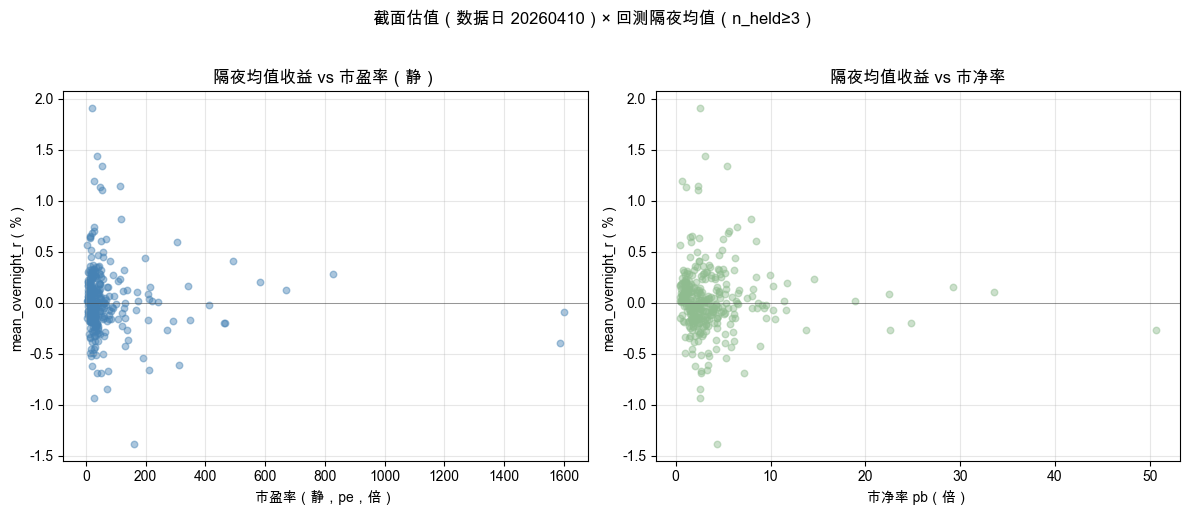

In [10]:
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Heiti TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(sub["pe_pos"], sub["mean_overnight_r"] * 100.0, s=22, alpha=0.45, c="steelblue")
ax.set_xlabel("市盈率（静，pe，倍）")
ax.set_ylabel("mean_overnight_r（%）")
ax.axhline(0, color="k", lw=0.5, alpha=0.5)
ax.set_title("隔夜均值收益 vs 市盈率（静）")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(sub["pb_pos"], sub["mean_overnight_r"] * 100.0, s=22, alpha=0.45, c="darkseagreen")
ax.set_xlabel("市净率 pb（倍）")
ax.set_ylabel("mean_overnight_r（%）")
ax.axhline(0, color="k", lw=0.5, alpha=0.5)
ax.set_title("隔夜均值收益 vs 市净率")
ax.grid(True, alpha=0.3)

fig.suptitle(f"截面估值（数据日 {DATE_STR}）× 回测隔夜均值（n_held≥{MIN_HELD}）", y=1.02)
fig.tight_layout()
plt.show()

## 解读提示

- **Spearman** 对极端 PE/PB 更稳健；**Pearson** 易受离群点影响。
- 若关心「**收益最低那一档**」是否对应高/低估值，重点看分位表 **Q1最低** 与 **Q4最高** 的 `median_pe` / `median_pb` 对比。
- 可改 `VALUATION_DATA_DATE` 与回测区间接近的日期，减少「估值日」与持仓样本的时间错位。
